<a href="https://colab.research.google.com/github/mohadesehsotoudehnia/AI-home-works/blob/main/miniProject1%20/%20MiniProject1_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Uploading DataSet And Necessary Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
import os

folder_name = "Titanic_DateSet"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

In [ ]:
%cd Titanic_DateSet

/content/Titanic_DateSet/Titanic_DateSet/Titanic_DateSet


In [ ]:
!pip install --upgrade --no--cache--dir gdown
!gdown 1a4nWn-kmc6fsH-cKpqJmFjrqAbq9DLlH


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --no--cache--dir
Downloading...
From: https://drive.google.com/uc?id=1a4nWn-kmc6fsH-cKpqJmFjrqAbq9DLlH
To: /content/Titanic_DateSet/Titanic_DateSet/Titanic_DateSet/Titanic-Dataset.csv
100% 61.2k/61.2k [00:00<00:00, 57.4MB/s]


# 1. Analysis DataSet

Reading DataFrame

In [ ]:
df = pd.read_csv("/content/Titanic_DateSet/Titanic-Dataset.csv")
df.info()
print("\n")
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB




,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Correlation Matrix

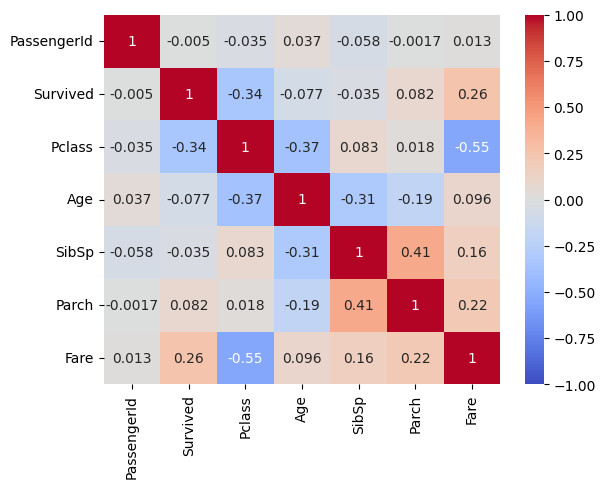

In [ ]:
numeric_df = df.select_dtypes(include=np.number)



corrMatrix = numeric_df.corr()
sns.heatmap(
    corrMatrix,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True)
plt.show()

Scatter and Hexbin

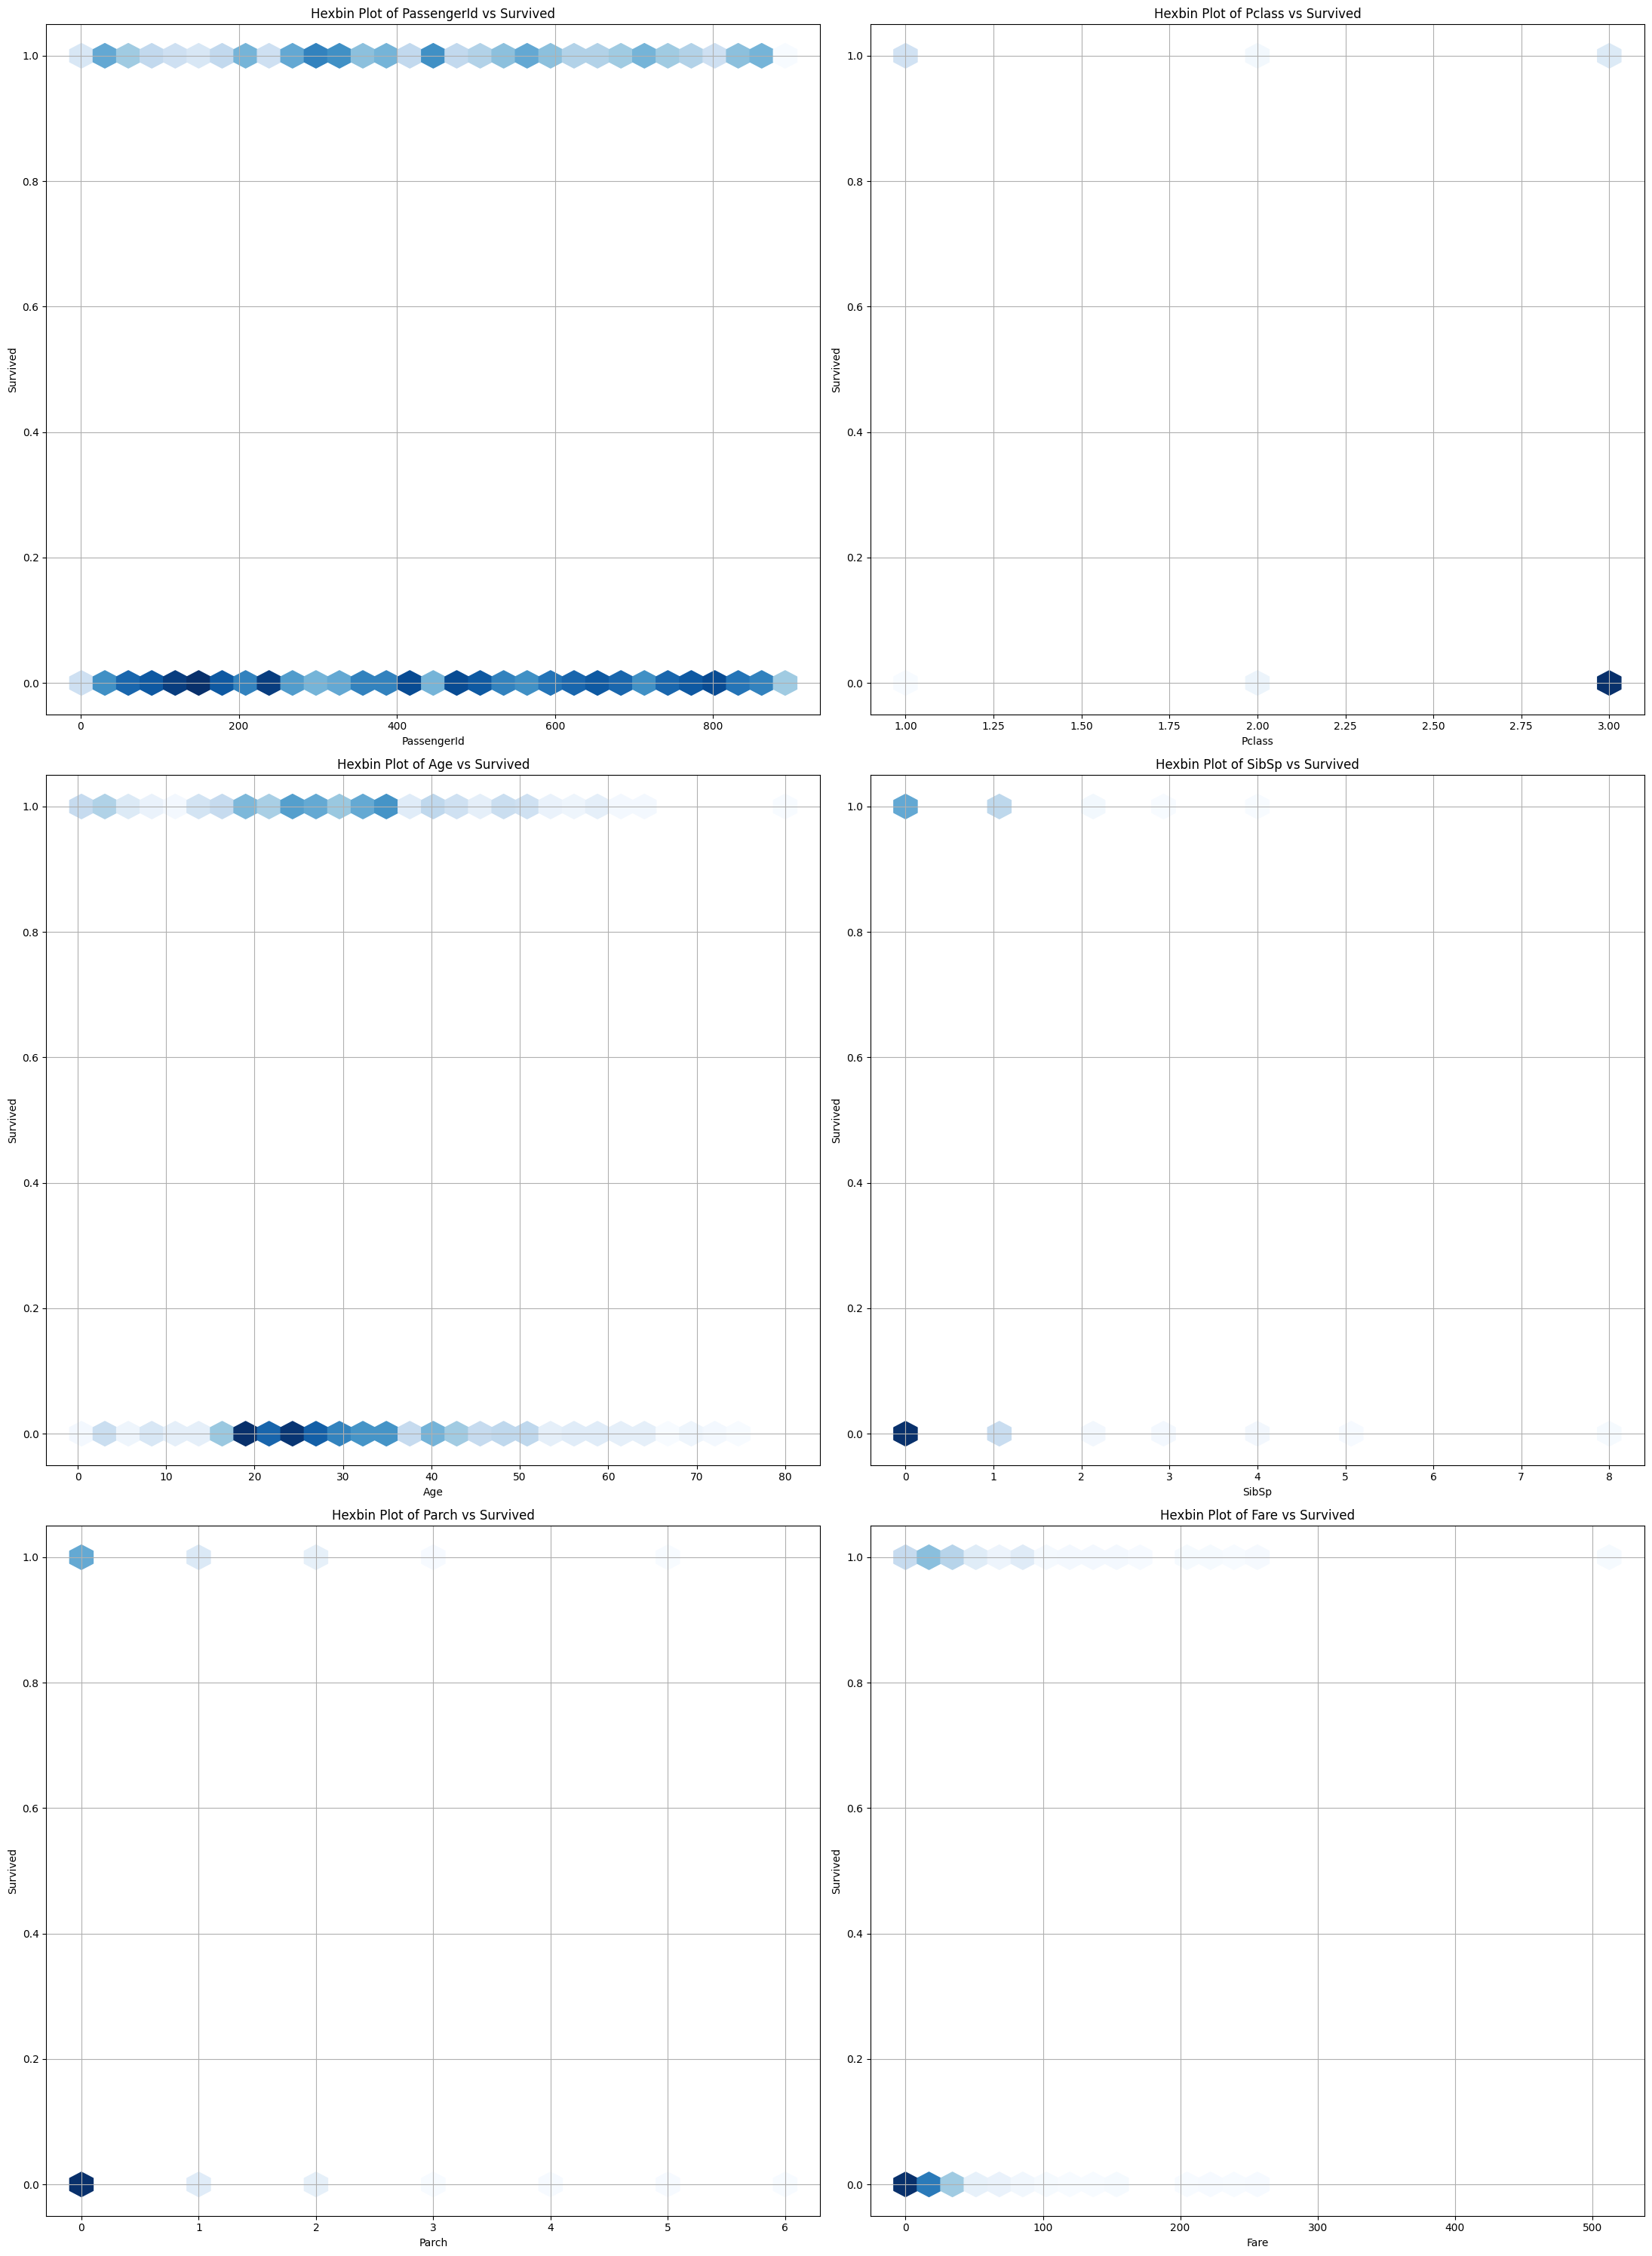

In [ ]:
X = numeric_df.drop(columns=["Survived"])
y = numeric_df["Survived"]

# Hexagonal binned plot
fig, axs = plt.subplots(nrows=int(X.shape[1]/2), ncols=2, figsize=(22,30))
axs = axs.ravel()
for i in range(X.shape[1]):
    axs[i].hexbin(X.iloc[:, i], y, gridsize=30, cmap="Blues", mincnt=1)
    axs[i].set_xlabel(X.columns[i])
    axs[i].set_ylabel("Survived")
    axs[i].set_title(f"Hexbin Plot of {X.columns[i]} vs Survived")
    axs[i].grid(True)


plt.tight_layout()

plt.show()

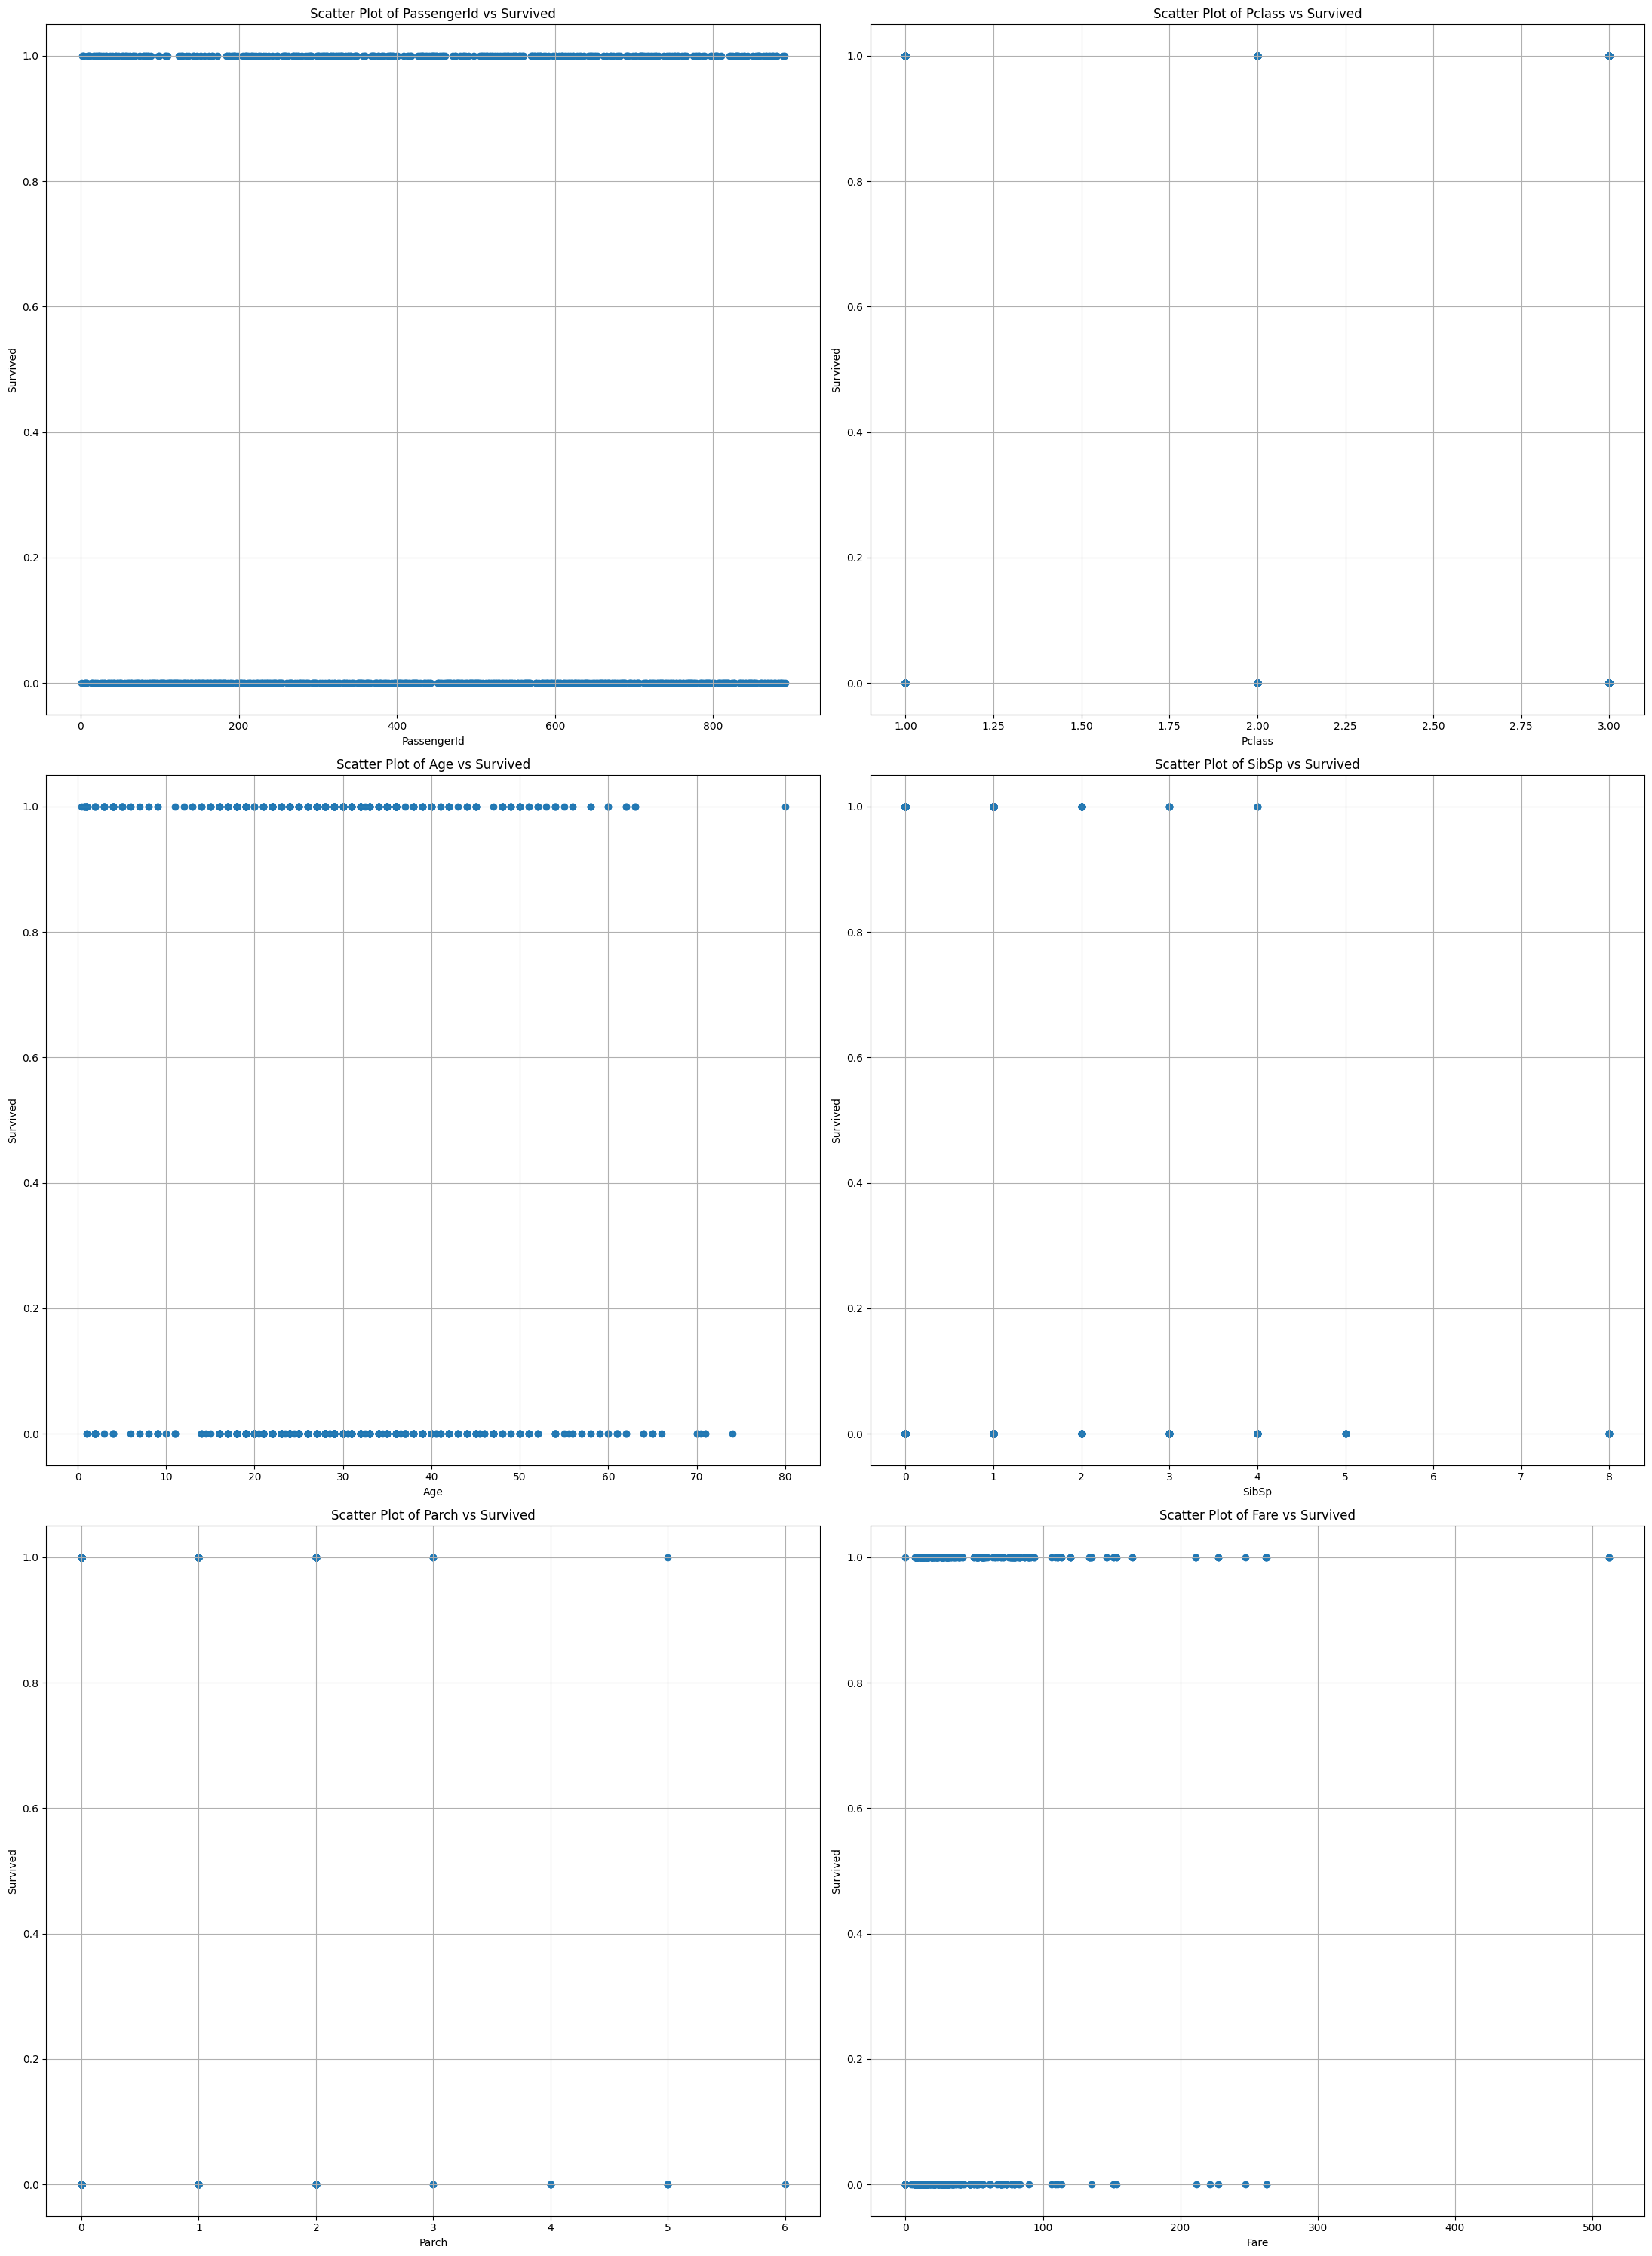

In [ ]:
# Scatter Plot

fig, axs = plt.subplots(nrows=int(X.shape[1]/2), ncols=2, figsize=(22,30))

axs = axs.ravel()

for i in range(X.shape[1]):
    axs[i].scatter(X.iloc[:, i], y)
    axs[i].set_xlabel(X.columns[i])
    axs[i].set_ylabel("Survived")
    axs[i].set_title(f"Scatter Plot of {X.columns[i]} vs Survived")
    axs[i].grid(True)


plt.tight_layout()

plt.show()

In [ ]:
import plotly.express as px
df_copy = df.copy()

df_copy.dropna(subset = ["Age", "Fare", "Survived"])

fig = px.scatter(df_copy, x="Age", y="Fare", color="Survived",
                color_discrete_map={0: "red", 1: "green"},
                title= "Survived Scatter Plot of Age vs Fare",
                labels={"Age": "Age", "Fare": "Fare", "Survived": "Survived"}
                )
fig.show()


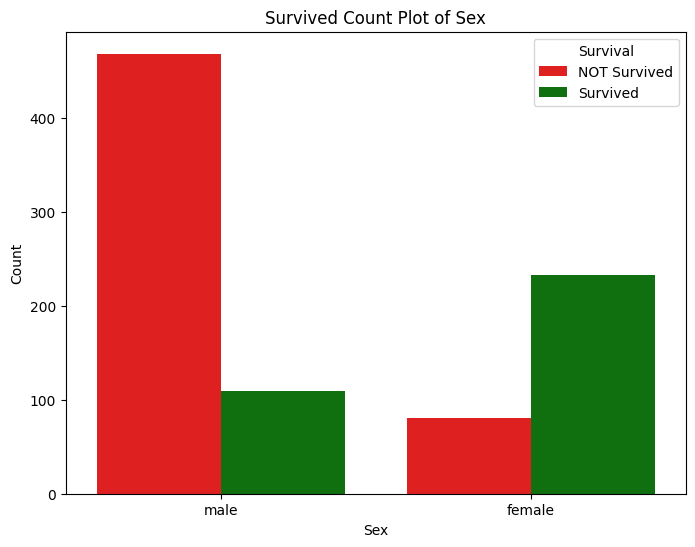

In [ ]:
df_copy.dropna(subset = ["Sex", "Survived"])

plt.figure(figsize=(8,6))

sns.countplot(data=df_copy, x="Sex", hue="Survived",  palette={0:"red", 1:"green"})
plt.title("Survived Count Plot of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Survival", labels = ["NOT Survived", "Survived"])
plt.show()

# DataSet Statistical Analysis

Checking family size vs Survival

In [ ]:
df_copy["Family Size"] = df_copy["SibSp"] + df_copy["Parch"] + 1  # +1 is because of him/herSelf

df_copy[["SibSp", "Parch", "Family Size", "Survived"]].head()

,SibSp,Parch,Family Size,Survived
0,1,0,2,0
1,1,0,2,1
2,0,0,1,1
3,1,0,2,1
4,0,0,1,0


<ipython-input-98-1a845a7194b0>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




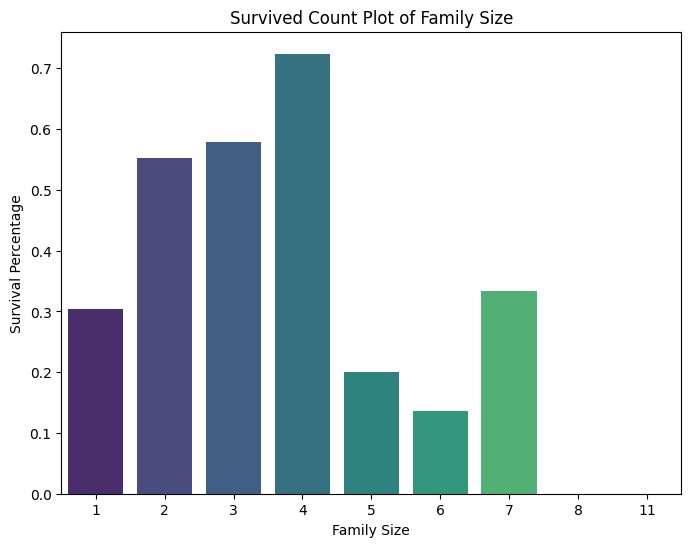

In [ ]:
df_copy.dropna(subset = ["Family Size", "Survived"])

plt.figure(figsize=(8,6))

sns.barplot(data=df_copy, x="Family Size", y="Survived", errorbar=None, palette="viridis")
plt.title("Survived Count Plot of Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Percentage")
plt.show()


Checking Age vs Survival

In [ ]:
df_copy.dropna(subset = ["Age"])

def categorize_Age(age):
  if age < 12:
    return "Child"
  elif 12 <= age <18:
    return "Teenager"
  elif 18 <= age < 30:
    return "Young Adult"
  elif 30 <= age < 55:
    return "Adult"
  else:
      return "Senior"

df_copy["AgeGroup"] = df_copy["Age"].apply(categorize_Age)

df_copy[["Age", "AgeGroup", "Survived"]].head()

,Age,AgeGroup,Survived
0,22.0,Young Adult,0
1,38.0,Adult,1
2,26.0,Young Adult,1
3,35.0,Adult,1
4,35.0,Adult,0


<ipython-input-100-50bdeec55707>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




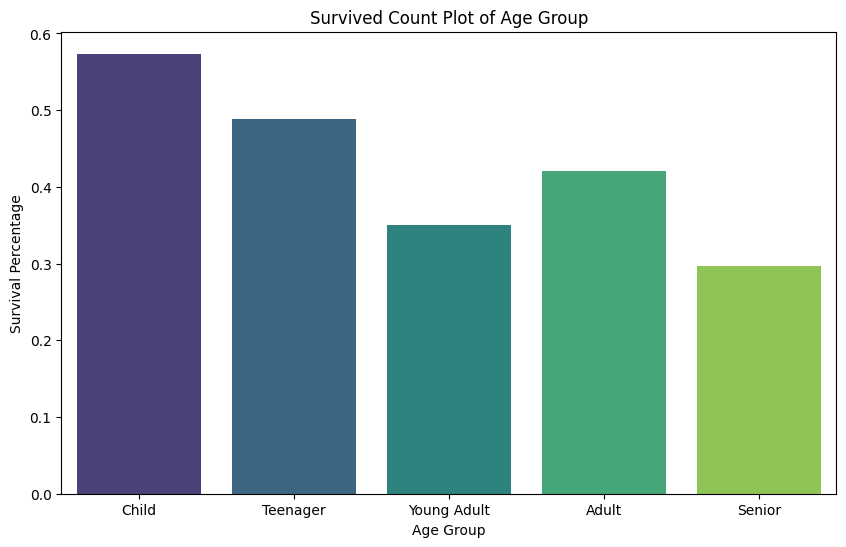

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_copy, x="AgeGroup", y="Survived", errorbar=None, palette="viridis",
            order = ["Child", "Teenager", "Young Adult", "Adult", "Senior"]
            )
plt.title("Survived Count Plot of Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Percentage")
plt.show()


# 2. DataSet PreProcessing

In [ ]:
missing_data = df.isnull().sum()

missing_Percent = (missing_data/len(df))*100

missing_df = pd.DataFrame({"Missing Values" : missing_data, "Percentage" : missing_Percent})
missing_df = missing_df[missing_df["Missing Values"] > 0]

print(missing_df)

          Missing Values  Percentage
Age                  177   19.865320
Cabin                687   77.104377
Embarked               2    0.224467


Filling Missing Data

Method 1 : Drop Missing Values

In [ ]:
df_drop = df.dropna(subset = ["Embarked"])

print(df_drop.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


Method 2 : Mean/Median Imputation

In [ ]:
# Mean
df_mean = df.copy()

df_mean["Age"].fillna(df["Age"].mean(), inplace = True)

# Median
df_median = df.copy()
df_median["Age"].fillna(df["Age"].median(), inplace = True)

print("For mean Method sum of the null data for Age feature is : ", df_mean["Age"].isnull().sum(),"\nAnd for Median Method is : ",
      df_median["Age"].isnull().sum())


For mean Method sum of the null data for Age feature is :  0 
And for Median Method is :  0


<ipython-input-103-cf7ece9c3acc>:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



<ipython-input-103-cf7ece9c3acc>:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

Method 3 : Mode Imputation

In [ ]:
df_mode = df.copy()

df_mode["Embarked"].fillna(df["Embarked"].mode()[0], inplace = True)


print("For Mode Method sum of the null data for Embarked Feature is :" ,df_mode["Embarked"].isnull().sum())


For Mode Method sum of the null data for Embarked Feature is : 0


<ipython-input-104-5bb6268e50b8>:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





Method 4 : Replacing Unknown

In [ ]:
df_unknown = df.copy()

df_unknown["Cabin"].fillna("Unknown", inplace = True)

print("For replacing Unknown, sum of the null data for Cabin Feature is : ", df_unknown["Cabin"].isnull().sum())


For replacing Unknown, sum of the null data for Cabin Feature is :  0


<ipython-input-105-cdbfad54e2e4>:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





dropping some columns

In [ ]:
df_cleaned = df.copy()
df_cleaned.drop(columns=['Cabin'], inplace=True)
df_cleaned.drop(columns=["PassengerId", "Ticket", "Name"], inplace=True)

print(df_cleaned.head())
print(df_cleaned.isnull().sum())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


Label Encoding for **Sex**

In [ ]:

from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
df_cleaned["Sex"] = LE.fit_transform(df_cleaned["Sex"]) # Male ---> 1 & Female ---> 0
print(df_cleaned["Sex"].head(),
      df["Sex"].head())

0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64 0      male
1    female
2    female
3    female
4      male
Name: Sex, dtype: object


One-Hot Encoding for **Embarked** and **PClass**

In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["Embarked", "Pclass"], drop_first=True)

df_cleaned.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,1,22.0,1,0,7.2500,False,True,False,True
1,1,0,38.0,1,0,71.2833,False,False,False,False
2,1,0,26.0,0,0,7.9250,False,True,False,True
3,1,0,35.0,1,0,53.1000,False,True,False,False
4,0,1,35.0,0,0,8.0500,False,True,False,True


Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_Features = ["Age", "Fare", "SibSp", "Parch"]

df_cleaned[num_Features] = scaler.fit_transform(df_cleaned[num_Features])
df_cleaned.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,1,-0.530377,0.432793,-0.473674,-0.502445,False,True,False,True
1,1,0,0.571831,0.432793,-0.473674,0.786845,False,False,False,False
2,1,0,-0.254825,-0.474545,-0.473674,-0.488854,False,True,False,True
3,1,0,0.365167,0.432793,-0.473674,0.420730,False,True,False,False
4,0,1,0.365167,-0.474545,-0.473674,-0.486337,False,True,False,True


In [ ]:
print(df_cleaned.isnull().sum())

Survived        0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked_Q      0
Embarked_S      0
Pclass_2        0
Pclass_3        0
dtype: int64


Final DateSet

In [ ]:
# as we mentioned in past for age null data we better use Median method

df_cleaned["Age"].fillna(df["Age"].median(), inplace = True)

print(df_cleaned.isnull().sum())


Survived      0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
Pclass_2      0
Pclass_3      0
dtype: int64


<ipython-input-111-364e8a71e6bc>:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





# 3. Feature Selection - Train - Evaluation

Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso

X = df_cleaned.drop(columns=["Survived"])
y = df_cleaned["Survived"]

lasso = Lasso(alpha=0.01)
lasso.fit(X, y)

selected_features_lasso = X.columns[np.abs(lasso.coef_) > 0]

print("Lasso Regression Selected Features : ", selected_features_lasso.tolist())


Lasso Regression Selected Features :  ['Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_S', 'Pclass_3']


Recursive Feature Elimination (RFE)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

LogReg = LogisticRegression(max_iter=500)

rfe = RFE(estimator=LogReg, n_features_to_select=5)
rfe.fit(X, y)

selected_features_rfe = X.columns[rfe.support_]

print("RFE Selected Features : ", selected_features_rfe)


RFE Selected Features :  Index(['Sex', 'SibSp', 'Embarked_S', 'Pclass_2', 'Pclass_3'], dtype='object')


Final Selected Features

In [ ]:
Final_selected_features = set(selected_features_lasso) | set(selected_features_rfe)

print("Final Selected Features : ", list(Final_selected_features))

Final Selected Features :  ['SibSp', 'Sex', 'Fare', 'Pclass_2', 'Age', 'Embarked_S', 'Pclass_3', 'Parch']


Odds Ratio

In [ ]:
X_selected = X[list(Final_selected_features)]
LogReg.fit(X_selected, y)

odds_ratios = np.exp(LogReg.coef_[0])

feature_importance = dict(zip(X_selected.columns, odds_ratios))

print("Odds Ratio : \n", feature_importance)

Odds Ratio : 
 {'SibSp': np.float64(0.782993871939605), 'Sex': np.float64(0.07506894900381683), 'Fare': np.float64(1.194796631534936), 'Pclass_2': np.float64(0.6273806759895707), 'Age': np.float64(0.9860508514785052), 'Embarked_S': np.float64(0.591600183534461), 'Pclass_3': np.float64(0.23260859676497908), 'Parch': np.float64(0.9285593129993897)}


Binary Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split

x_train_binary, x_test, y_train_binary, y_test = train_test_split(X_selected, y,
                                                    test_size=0.2,random_state=73)

binary_model = LogReg.fit(x_train_binary, y_train_binary)

y_test_pred = binary_model.predict(x_test)
y_train_pred =binary_model.predict(x_train_binary)

Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train_binary, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy : ", train_accuracy)
print("Test Accuracy : ", test_accuracy)

Train Accuracy :  0.800561797752809
Test Accuracy :  0.8156424581005587


Confusion Matrix

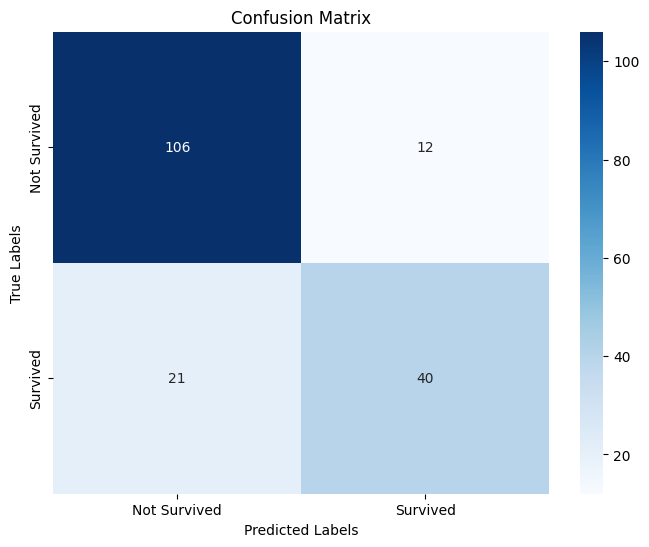

In [ ]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Survived", "Survived"],
            yticklabels=["Not Survived", "Survived"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

ROC and AUC

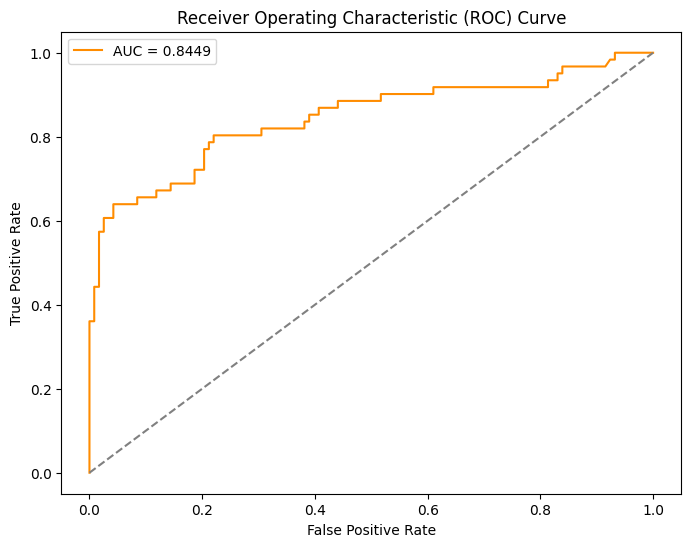

In [ ]:
from sklearn.metrics import roc_curve, auc

y_test_prob = LogReg.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_test_prob)

roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="darkorange", label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()

Multinomial & one-vs-rest Logistic Regression

New survival classes

In [ ]:
# Age > 50 & Pclass = 3          ----> 0 (Low Chance)
# Sex = 0 (Female) Or Pclass = 1 ----> 2 (High Chance)
# Other                          ----> 1 (Medium Chance)

df_cleaned["SurvivalClass"] = np.where((df_cleaned["Sex"] == 0) & (df_cleaned["Pclass_2"] == False) & (df_cleaned["Pclass_3"] == False), 2,
                                       np.where((df_cleaned["Age"] > 50) | (df_cleaned["Pclass_3"] == True), 0, 1))


print(df_cleaned["SurvivalClass"].value_counts())


SurvivalClass
0    491
1    306
2     94
Name: count, dtype: int64


multiClass train and test splitting

In [ ]:
# X_selected same as past

y_multiclass = df_cleaned["SurvivalClass"]

X_train_multi, X_test, y_train_multi, y_test = train_test_split(X_selected, y_multiclass,
                                                    test_size=0.2, random_state=73)


MultiNomial Logistic Regression

In [ ]:
MultiNomial_model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000)

MultiNomial_model.fit(X_train_multi, y_train_multi)

y_test_pred_multinomial = MultiNomial_model.predict(X_test)

accuracy_multinomial = accuracy_score(y_test, y_test_pred_multinomial)

print(f"Accuracy of MultiNomial Logestic Regression : {accuracy_multinomial:.4f}")

Accuracy of MultiNomial Logestic Regression : 1.0000


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



One-vs-Rest Logistic Regression

In [ ]:
ovr_model = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=1000)

ovr_model.fit(X_train_multi, y_train_multi)

y_test_pred_ovr = ovr_model.predict(X_test)

accuracy_ovr = accuracy_score(y_test, y_test_pred_ovr)

print(f"Accuracy of One-vs-Rest Logestic Regression : {accuracy_ovr:.4f}")

Accuracy of One-vs-Rest Logestic Regression : 1.0000


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.



In [ ]:
print(f"Accuracy of MultiNomial Logestic Regression : {accuracy_multinomial:.4f}")
print(f"Accuracy of One-vs-Rest Logestic Regression : {accuracy_ovr:.4f}")

Accuracy of MultiNomial Logestic Regression : 1.0000
Accuracy of One-vs-Rest Logestic Regression : 1.0000


Binary Logistic Regression Coefficients

In [ ]:
features_coefs = pd.DataFrame({"Features":x_train_binary.columns, "Coefficient":binary_model.coef_[0]})

features_coefs["Odds Ratio"] = np.exp(features_coefs["Coefficient"])

features_coefs = features_coefs.sort_values(by="Coefficient", ascending=False)

print(features_coefs)

     Features  Coefficient  Odds Ratio
2        Fare     0.150193    1.162058
4         Age    -0.011503    0.988563
7       Parch    -0.108985    0.896744
0       SibSp    -0.249000    0.779580
3    Pclass_2    -0.416194    0.659552
5  Embarked_S    -0.492812    0.610906
6    Pclass_3    -1.366951    0.254883
1         Sex    -2.592549    0.074829


MultiClass Logistic Regression Coefficients

In [ ]:
multi_class_coefficient = pd.DataFrame(MultiNomial_model.coef_.T,
                                       columns=["Low Chance", "Medium Chance", "High Chance"],
                                       index=X_train_multi.columns)

multi_class_odds = np.exp(multi_class_coefficient)
print("Coefficent: \n", multi_class_coefficient)
print("--------------------------------------------------\n", "Odds Ratio: \n")
print(multi_class_odds)


Coefficent: 
             Low Chance  Medium Chance  High Chance
SibSp         0.317725      -0.249146    -0.068579
Sex           0.261251       2.846145    -3.107396
Fare         -1.403187       0.577095     0.826091
Pclass_2     -0.932833       3.130960    -2.198127
Age           0.010427      -0.001889    -0.008538
Embarked_S   -0.027370       0.137253    -0.109883
Pclass_3      4.417561      -2.732704    -1.684857
Parch         0.142868      -0.005172    -0.137696
--------------------------------------------------
 Odds Ratio: 

            Low Chance  Medium Chance  High Chance
SibSp         1.373999       0.779466     0.933719
Sex           1.298553      17.221266     0.044717
Fare          0.245812       1.780858     2.284372
Pclass_2      0.393437      22.895946     0.111011
Age           1.010482       0.998113     0.991498
Embarked_S    0.973002       1.147118     0.895939
Pclass_3     82.893858       0.065043     0.185471
Parch         1.153578       0.994841     0.871363
